**Load dataset**


In [5]:
import pandas as pd
df=pd.read_csv("marketing_and_sales_data.csv")
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


**Statistics Summary of Data**

In [7]:
df.describe()

,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


In [8]:
print (df.dtypes)

TV               object
Radio           float64
Social Media    float64
Influencer       object
Sales           float64
dtype: object


In [9]:
df.duplicated().sum()

np.int64(0)

Exploratory data analysis:
value counts for TV and Influencer (Categorical variables)

In [10]:
df['TV'].value_counts()

,count
TV,
Medium,205
Low,201
High,166


In [11]:
df['Influencer'].value_counts()

,count
Influencer,
Nano,157
Micro,151
Mega,137
Macro,127


Univariate Analysis:
Count plot for TV(categorical)

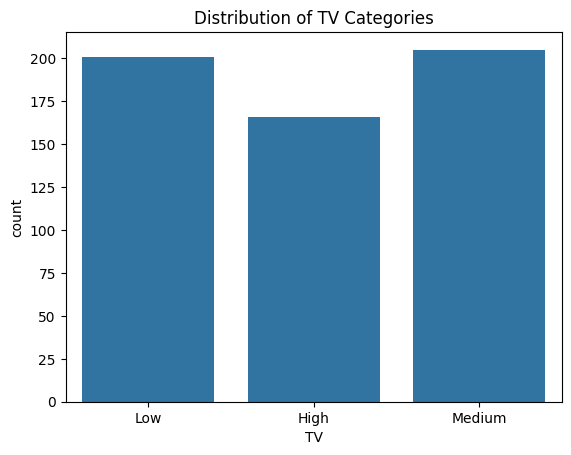

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='TV', data=df)
plt.title('Distribution of TV Categories')
plt.show()

Count plot for Influencer(categorical)

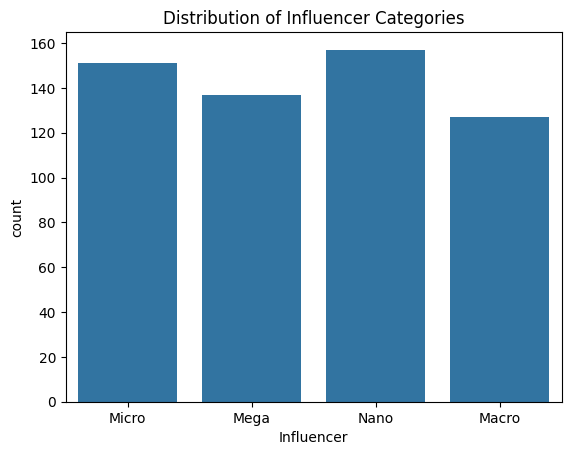

In [13]:
sns.countplot(x='Influencer', data=df)
plt.title('Distribution of Influencer Categories')
plt.show()

Histogram plot for numerical variables:
Distribution of marketing spend and sales

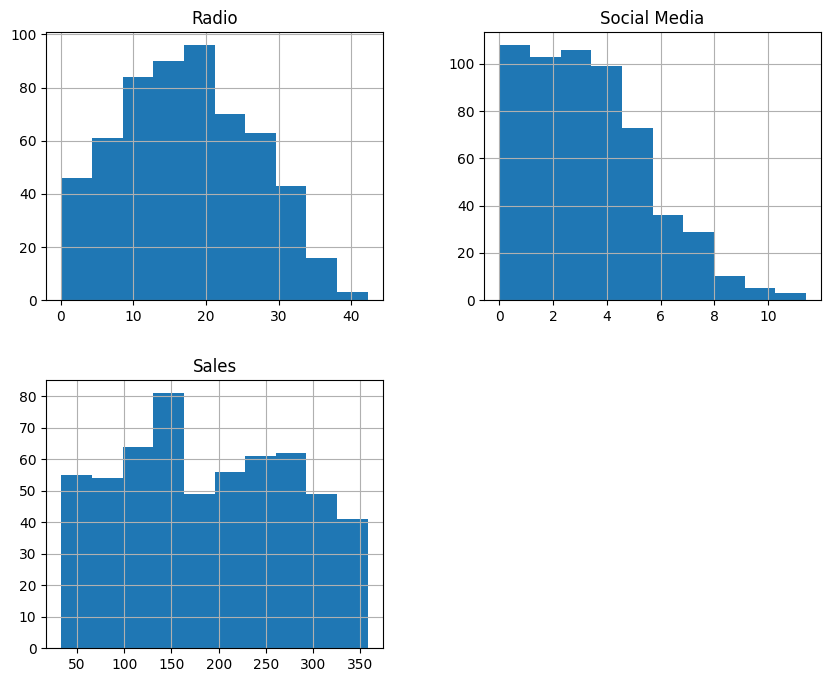

In [14]:
import matplotlib.pyplot as plt
df.hist(figsize=(10,8))
plt.show()

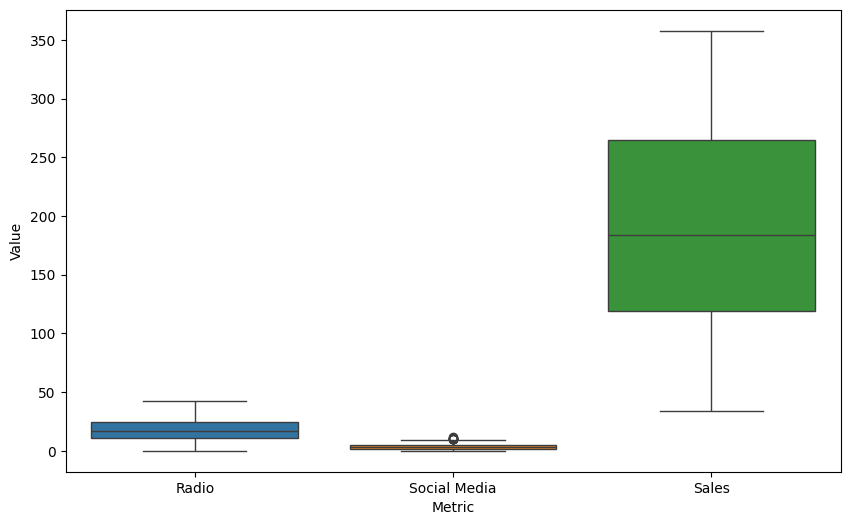

In [15]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.ylabel('Value')
plt.xlabel('Metric')
plt.show()

Interpretation of boxplots of marketing spend
1.** Radio:**
Radio spending varies quite a bit
No extreme outliers → fairly stable channel
Likely has a moderate influence on sales
2.**social media:**
Most values are clustered → low variability
A few spikes (outliers) suggest occasional high campaigns
Overall: least influential or least invested channel
3.**sales**
Sales vary a lot → high variability
This is expected since it's the dependent variable
Suggests multiple factors (not just one channel) influence sales


Bivariate Analysis
TV vs Sales

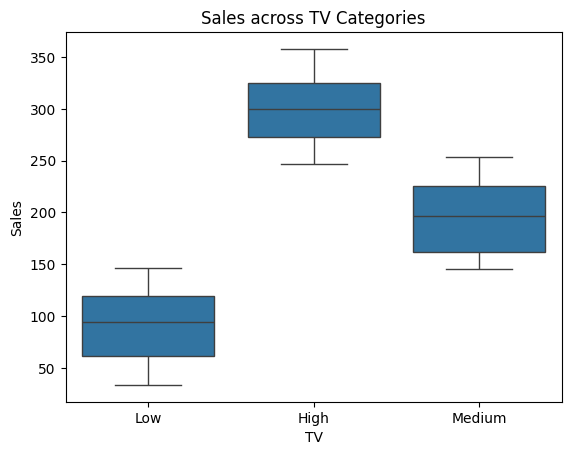

In [16]:
sns.boxplot(x='TV', y='Sales', data=df)
plt.title('Sales across TV Categories')
plt.show()

1. TV-low:
Low TV spend → low sales
Weak performance
2. TV-medium:
Medium TV spend → highest sales
This is interesting — suggests optimal spending level
3.TV-High:
High TV spend does NOT give highest sales
Possible diminishing returns
Overspending may not be efficient
“Sales increase significantly from low to medium TV spend, but decline at high levels, suggesting diminishing returns. Radio shows moderate variability, while social media has minimal variation and likely low impact.”

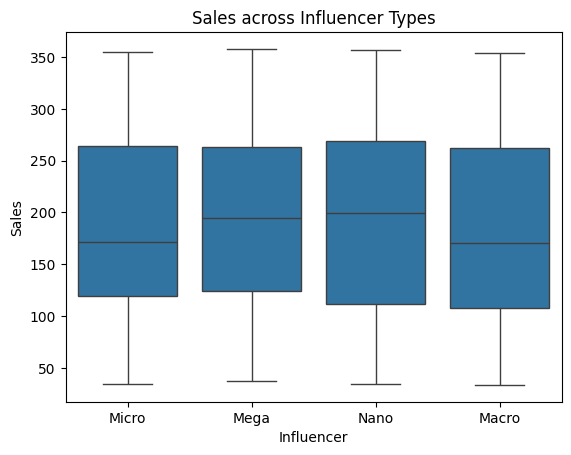

In [17]:

sns.boxplot(x='Influencer', y='Sales', data=df)
plt.title('Sales across Influencer Types')
plt.show()

Radio vs sales


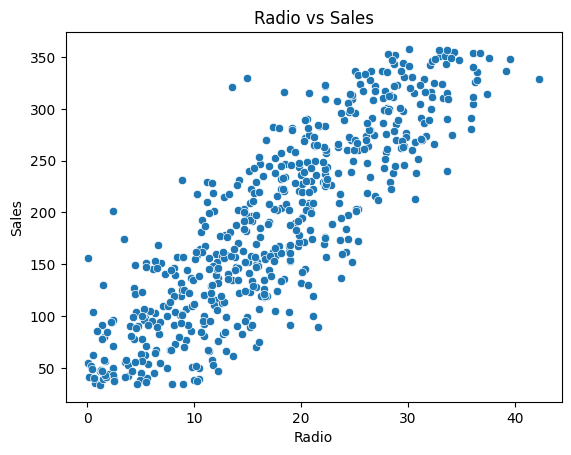

In [18]:
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title('Radio vs Sales')
plt.show()

Social Media vs sales


<Axes: xlabel='Social Media', ylabel='Sales'>

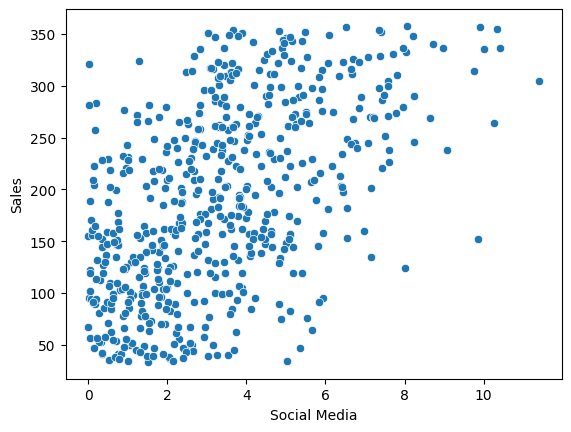

In [19]:
sns.scatterplot(x='Social Media', y='Sales', data=df)

Convert cagorical variables to dummy variables by encoding


In [20]:

# Create dummy variables
X = pd.get_dummies(
    df[['TV', 'Radio', 'Social Media']],
    drop_first=True
)

print(X.head())


       Radio  Social Media  TV_Low  TV_Medium
0   3.518070      2.293790    True      False
1   7.756876      2.572287    True      False
2  20.348988      1.227180   False      False
3  20.108487      2.728374   False       True
4  31.653200      7.776978   False      False


check for multicollinearity among independent variables(TV, Radio and Social media) using correlation matrix and VIF

                 Radio  Social Media    TV_Low  TV_Medium
Radio         1.000000      0.629941 -0.674203   0.004400
Social Media  0.629941      1.000000 -0.423910  -0.008272
TV_Low       -0.674203     -0.423910  1.000000  -0.550117
TV_Medium     0.004400     -0.008272 -0.550117   1.000000


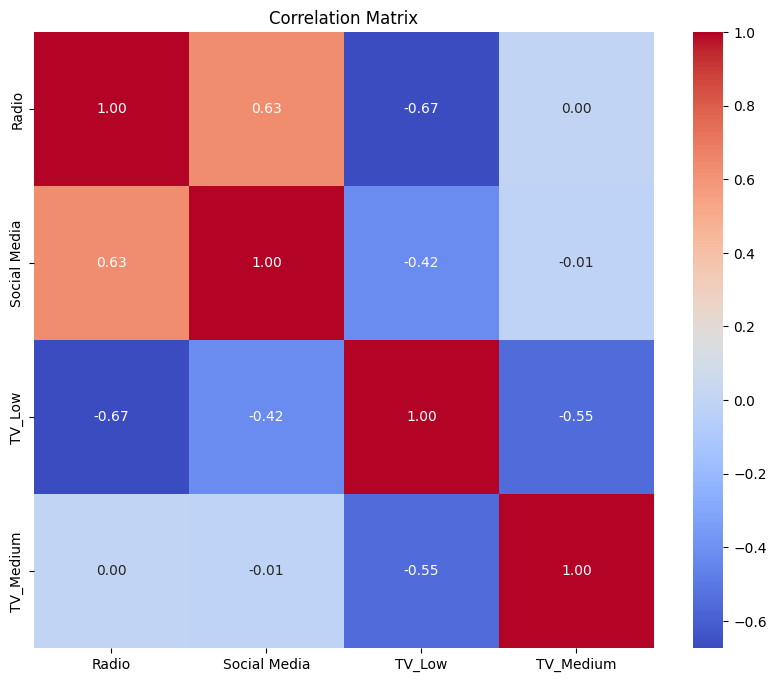

In [21]:
#using correlation matrix to check for multicollinearity
corr = X.corr()

print(corr)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


Interpretation
1. Radio and Social Media (0.630)
This is a moderately strong positive correlation.
As Radio advertising increases, Social Media advertising also tends to increase.
It is not high enough to suggest serious multicollinearity.
2. Radio and TV_Low (-0.674)

This negative correlation is expected because TV_Low is a dummy variable.
It means that observations with Low TV advertising tend to have lower Radio advertising than observations in the reference or other TV categories. This does not necessarily indicate a multicollinearity problem.

3. TV_Low and TV_Medium (-0.550)

This is also expected.
An observation cannot be both Low and Medium at the same time, so these dummy variables are naturally negatively correlated.

4. TV_Medium with Radio (0.004) and Social Media (-0.008)

These are essentially zero, meaning there is almost no linear relationship.

Here are the key pairwise relationships:

Radio ↔ Social Media = 0.630 → Moderate positive correlation.
Radio ↔ TV_Low = -0.674 → Moderate negative correlation (expected because TV_Low is a dummy).
Social Media ↔ TV_Low = -0.424 → Moderate negative correlation.
Radio ↔ TV_Medium = 0.004 → No correlation.
Social Media ↔ TV_Medium = -0.008 → No correlation.

In [22]:
#using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Convert ALL columns to float
X = X.astype("float64")
# Calculate VIF
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.to_numpy(), i)
    for i in range(X.shape[1])
]

print(vif)

       Variable       VIF
0         Radio  5.464372
1  Social Media  5.304131
2        TV_Low  1.138887
3     TV_Medium  1.443547


The interpretation

VIF < 5: No problematic multicollinearity.
VIF > 5: Potential multicollinearity.
VIF > 10: Serious multicollinearity.

Using the more conservative threshold of 5:

Radio (VIF = 5.464) indicates moderate multicollinearity.
Social Media (VIF = 5.304) also indicates moderate multicollinearity.
TV_Low (VIF = 1.139) indicates no multicollinearity.
TV_Medium (VIF = 1.444) indicates no multicollinearity.

Performing multiple linear regression

In [28]:
import statsmodels.api as sm
X = X.astype(float)
X = sm.add_constant(X)
y = df['Sales']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1335.
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          7.29e-287
Time:                        01:13:40   Log-Likelihood:                -2713.9
No. Observations:                 572   AIC:                             5438.
Df Residuals:                     567   BIC:                             5460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          218.6473      6.290     34.761   

In [29]:
#predict sales
df['Predicted_Sales'] = model.predict(X)
#compare predicted sales vs actual sales
comparison = df[['Sales', 'Predicted_Sales']]
print(comparison.head())

        Sales  Predicted_Sales
0   55.261284        74.507260
1   67.574904        87.135850
2  272.250108       279.289090
3  195.102176       203.017231
4  273.960377       312.096721


1. Adjusted R-squared

The model has an Adjusted R-squared of 0.903.

Interpretation:

The model explains approximately 90.3% of the variation in Sales after adjusting for the number of predictors included in the model.
This indicates that the model has excellent explanatory power, suggesting that the selected predictors collectively provide a strong fit to the data.
2. Individual predictor p-values

The p-value for each predictor determines whether it makes a statistically significant contribution to predicting Sales. A common significance levelis 0.05.

	Interpretation
1. Radio	(p<0.001)	:Radio advertising significantly predicts Sales.

2. Social Media	p=0.824, (p>0.05):		Social Media advertising does not significantly predict Sales after controlling for the other predictors.
3. TV_Low	(p<0.001):	Low TV advertising has a significant effect on Sales compared with the reference category (High TV).
4. TV_Medium	(p<0.001):	Medium TV advertising also has a significant effect on Sales compared with High TV.
Overall evaluation

Based on the Adjusted R-squared (0.903), the multiple linear regression model fits the data very well, explaining approximately 90.3% of the variability in Sales.

Among the predictors, Radio, TV_Low, and TV_Medium are statistically significant predictors of Sales because their p-values are less than 0.05. However, Social Media is not statistically significant (p = 0.824), indicating that it does not contribute meaningfully to predicting Sales when the effects of Radio and TV are already included in the model.

In [30]:
#obtaining the fitted values and residuas
import matplotlib.pyplot as plt
from scipy import stats

# Predicted (fitted) values
fitted = model.fittedvalues

# Residuals
residuals = model.resid

checking for Linearity

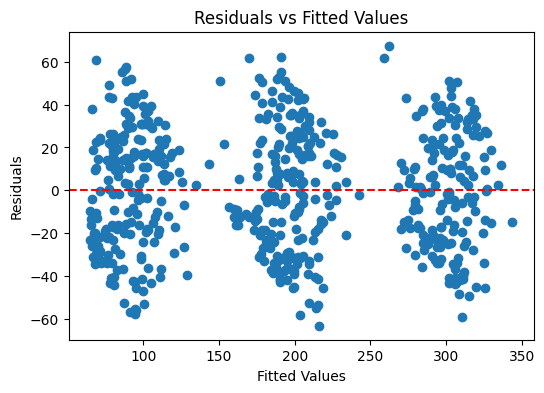

In [31]:
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

checking for Normality

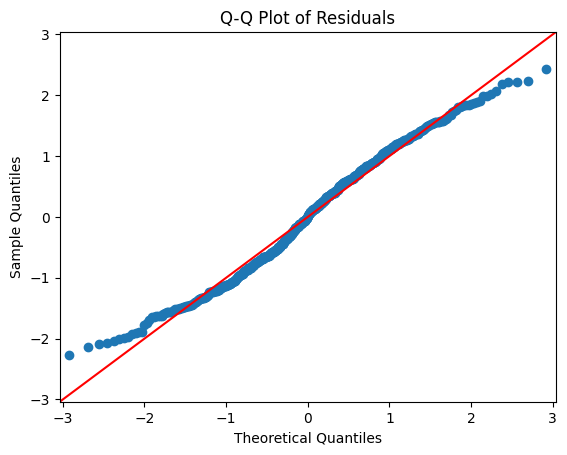

In [32]:
import statsmodels.api as sm

sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

Checking for Homoscedacity

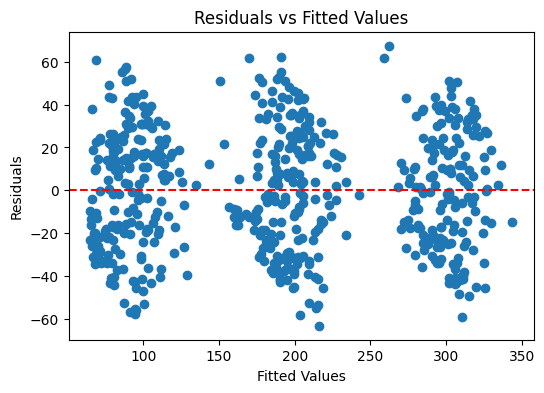

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

What the linearity plot shows

The plot has three distinct clusters, which is expected because TV is a categorical variable with three levels (High, Medium, and Low). Each cluster corresponds to one of the TV categories.

Within each cluster:

the residuals are scattered both above and below the zero line,
there is no obvious curved pattern,
there is no increasing or decreasing trend.

Therefore, the plot suggests that the relationship between the predictors and Sales is adequately represented by a linear model.

 interpretation

The Residuals vs Fitted plot shows that the residuals are randomly scattered around the zero line with no obvious systematic or curved pattern. Although three distinct clusters are visible due to the categorical TV variable, the absence of a clear trend indicates that the linearity assumption is reasonably satisfied.

What the Q_Q plot shows
The points track the red 45° line closely in the middle → this suggests the bulk of the residuals are approximately normally distributed.
There is a slight systematic curve (S-like pattern) at the extremes:
Left tail (low quantiles) sits a bit above the line
Right tail (high quantiles) sits a bit below the line
Interpretation

This  pattern usually indicates a mild departure from perfect normality, specifically:

The residuals appear to have slightly lighter tails than a normal distribution (platykurtic behavior)
→ meaning fewer extreme errors than a perfect normal distribution would expect.
What it means for the model
No major violation of normality
Central assumption of OLS is reasonably satisfied
Minor tail deviation, but typically not serious enough to invalidate inference

what the homoscedacity plot shows
Looking across the three clusters:

the vertical spread is fairly similar,
there is no obvious funnel or cone shape,
the variability does not noticeably increase or decrease as the fitted values increase.

There are a few observations with larger residuals (around ±60), but these appear to be isolated points rather than a systematic pattern.

Overall, this suggests that the variance of the residuals is approximately constant.

 interpretation

The Residuals vs Fitted plot indicates that the residuals exhibit a relatively constant spread across the range of fitted values. There is no clear funnel or cone-shaped pattern, suggesting that the assumption of homoscedasticity is reasonably satisfied. Although a few observations have relatively large residuals, they do not appear to indicate a systematic violation of this assumption.

The efect of 1 unit of spend on one channel while holding others constant

The coefficient for Radio advertising was 2.989 (p < 0.001), indicating that, holding TV advertising level and Social Media spending constant, a one-unit increase in Radio advertising is associated with an average increase of approximately 2.99 units in Sales.

The coefficient for Social Media advertising was −0.150 (p = 0.824), suggesting a slight negative relationship with Sales. However, this effect was not statistically significant, indicating insufficient evidence that Social Media advertising influences Sales after controlling for the other predictors.

Compared with High TV advertising (the reference category), campaigns with Low TV advertising were associated with approximately 154.31 fewer units of Sales, while campaigns with Medium TV advertising were associated with approximately 75.33 fewer units of Sales, after controlling for Radio and Social Media advertising. Both effects were statistically significant (p < 0.001).

Findings and recommendaton
The multiple linear regression analysis indicates that the model provides an excellent fit to the data, explaining approximately 90.3% of the variation in Sales (Adjusted R² = 0.903). This suggests that the selected advertising channels are strong predictors of sales performance.

Among the advertising channels, Radio advertising was found to have a statistically significant positive effect on Sales. Specifically, holding the other predictors constant, each one-unit increase in Radio advertising expenditure is associated with an average increase of approximately 2.99 units in Sales. This indicates that increasing investment in Radio advertising is likely to generate higher sales.

The analysis also showed that TV advertising level has a significant influence on Sales. Campaigns with Low and Medium TV advertising levels were associated with substantially lower Sales compared with High TV advertising. This suggests that maintaining a High level of TV advertising is important for achieving stronger sales performance.

In contrast, Social Media advertising was not found to have a statistically significant effect on Sales after accounting for Radio and TV advertising. This suggests that, within the scope of this analysis, increasing Social Media advertising expenditure alone may not lead to a measurable improvement in Sales.

Recommendation

Based on these findings, the company should prioritise investment in Radio advertising and maintain a High TV advertising strategy, as both have demonstrated significant positive contributions to Sales. Given the lack of statistical evidence supporting the effectiveness of Social Media advertising in this model, the company should review its Social Media campaigns to assess whether the budget is being used effectively or whether improvements in targeting, content, or campaign strategy are needed. Future analyses could also investigate additional factors that may influence Sales to further improve marketing decision-making.
